In [1]:
# Uncomment to install pystac_client package
# !pip install pystac_client

In [2]:
# Load Client class from PySTAC Client
from pystac_client import Client

In [3]:
# Connect to Earth Search catalog
client = Client.open("https://earth-search.aws.element84.com/v1/")
client

<Client id=earth-search-aws>

In [4]:
# Get collections (returns a generator)
collections = client.get_collections()
collections

<generator object Client.get_collections at 0x000002234BB1E130>

In [5]:
# List collection ids
# REMARK: Because collection is a generator, you can iterate only once
for collection in collections:
    print(collection.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


In [6]:
# Get Sentinel 2 L2A collection
collection = client.get_collection("sentinel-2-l2a")
collection

<CollectionClient id=sentinel-2-l2a>

In [7]:
# Search for all records in the collection
results = client.search(
    collections=["sentinel-2-l2a"]
)

In [8]:
# Display the number of matched items
results.matched()

43211205

In [9]:
# Set point of interest (Enschede)
point = {
    "type": "Point",
    "coordinates": (6.89437, 52.22088)
}

In [10]:
# Search for items around Enschede for 2025 and less than 5% cloud coverage, limiting the number of returned items
results = client.search(
    collections=["sentinel-2-l2a"],
    intersects=point,
    datetime="2025-01-01/2025-12-31",
    query=["eo:cloud_cover<5"],
    max_items=10
)

In [11]:
# Display the number of matched items, which might be different from max_items
results.matched()

32

In [12]:
# Get items. This may take time if the number of items is large.
items = results.item_collection()
items

In [13]:
# Get the first item
item = items[0]
item

<Item id=S2C_31UGT_20250819_0_L2A>

In [14]:
# Display date and time of the item
# REMARK: Items are not sorted by default; hence, there is no guarantee that the first item is the oldest item
item.datetime

datetime.datetime(2025, 8, 19, 10, 46, 56, 498000, tzinfo=tzutc())

In [15]:
# Display bounding box of the item
item.bbox

[5.870231, 51.278935, 7.539964, 52.314028]

In [16]:
# Uncomment to install visualization packages
# !pip install geopandas folium mapclassify matplotlib

In [17]:
# Import geopandas
import geopandas

In [18]:
# Create geodatafrom from item
gdf = geopandas.GeoDataFrame.from_features([item], crs="epsg:4326")

In [19]:
# Display geodataframe
gdf

,geometry,created,platform,constellation,instruments,eo:cloud_cover,proj:centroid,mgrs:utm_zone,mgrs:latitude_band,mgrs:grid_square,...,s2:datastrip_id,s2:reflectance_conversion_factor,datetime,s2:sequence,earthsearch:s3_path,earthsearch:payload_id,earthsearch:boa_offset_applied,processing:software,updated,proj:code
0,"POLYGON ((5.93363 52.31403, 5.87023 51.32808, ...",2025-08-19T17:30:21.601Z,sentinel-2c,sentinel-2,[msi],0.069535,"{'lat': 51.79783, 'lon': 6.69653}",31,U,GT,...,S2C_OPER_MSI_L2A_DS_2CPS_20250819T155312_S2025...,0.975247,2025-08-19T10:46:56.498000Z,0,s3://sentinel-cogs/sentinel-s2-l2a-cogs/31/U/G...,roda-sentinel2/workflow-sentinel2-to-stac/54d6...,True,{'sentinel2-to-stac': '2025.03.06'},2025-08-19T17:30:21.601Z,EPSG:32631


In [20]:
# Display item on a map
gdf.explore()

In [21]:
# Display assets of the item
item.assets

{'aot': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/AOT.tif>,
 'blue': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/B02.tif>,
 'cloud': <Asset href=s3://sentinel-s2-l2a/tiles/31/U/GT/2025/8/19/0/qi/CLD_20m.jp2>,
 'coastal': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/B01.tif>,
 'granule_metadata': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/granule_metadata.xml>,
 'green': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/B03.tif>,
 'nir': <Asset href=https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/B08.tif>,
 'nir08': <Asset href=https://sentinel-co

In [22]:
# Display URL address of the thumbnail image
item.assets["thumbnail"].href

'https://sentinel-cogs.s3.us-west-2.amazonaws.com/sentinel-s2-l2a-cogs/31/U/GT/2025/8/S2C_31UGT_20250819_0_L2A/preview.jpg'

In [23]:
# Save thumbnail image in a local file
import urllib.request
urllib.request.urlretrieve(item.assets["thumbnail"].href, "thumbnail.jpg")

('thumbnail.jpg', <http.client.HTTPMessage at 0x2230f46c8f0>)

In [24]:
# Display thumbnail image in the notebook
from IPython.display import Image

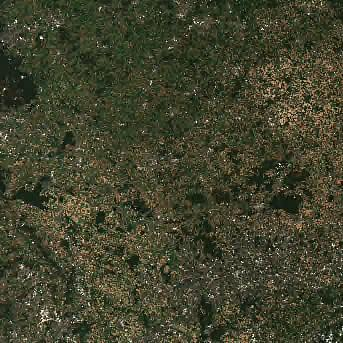

In [25]:
image = Image("thumbnail.jpg")
image

In [26]:
# Uncomment to install rioxarray package
# !pip install rioxarray

In [27]:
# Import rioxarray package. It will enable us to get data easily.
import rioxarray

In [28]:
# Open NIR band as xarray
nir = rioxarray.open_rasterio(item.assets["nir"].href)
nir

<xarray.DataArray (band: 1, y: 10980, x: 10980)> Size: 241MB
[120560400 values with dtype=uint16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 88kB 5.8e+06 5.8e+06 5.8e+06 ... 5.69e+06 5.69e+06
  * x            (x) float64 88kB 7e+05 7e+05 7e+05 ... 8.097e+05 8.098e+05
    spatial_ref  int64 8B 0
Attributes:
    OVR_RESAMPLING_ALG:  AVERAGE
    AREA_OR_POINT:       Area
    _FillValue:          0
    scale_factor:        1.0
    add_offset:          0.0

In [29]:
# Import matplotlib plot
import matplotlib.pyplot as plt

284 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)


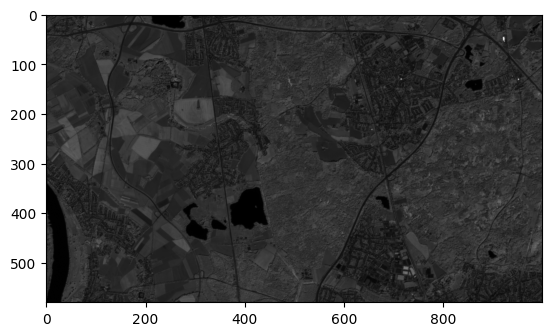

In [30]:
%%timeit -n 5 -r 1
# Display a small part of the NIR data. This will be quick, as xarray will download only needed data in a cloud-native way
plt.imshow(nir[0,10400:10980,6000:7000], cmap="gray")

9.68 s ± 0 ns per loop (mean ± std. dev. of 1 run, 5 loops each)


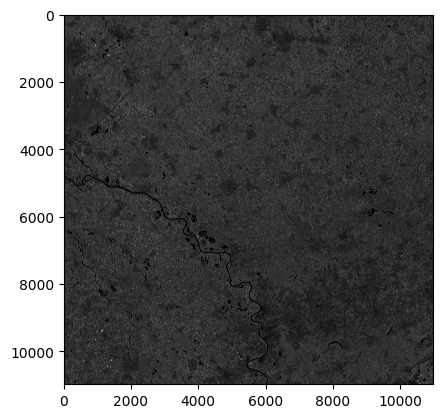

In [31]:
%%timeit -n 5 -r 1
# Display all of the NIR band. This requires download of all data; hence, it is slower.
plt.imshow(nir[0,:,:], cmap="gray")